<a href="https://colab.research.google.com/github/dowsettl/lehua-dowsett/blob/main/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lehua Dowsett

*Intro to Neural Data Analysis*

**4/10/2026**

In [89]:
# I imported matplotlib, numpy, and pearsonr from scipy.stats

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr


In [90]:
# I used numpy in order to simplify the data sets
url_1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
url_2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
url_3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
url_4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'

fear_traces = np.loadtxt(url_1, delimiter = ',')
extinction_predictors = np.loadtxt(url_2, delimiter = ',')
shock_index = np.loadtxt(url_3, delimiter = ',').astype(int)
tone_index = np.loadtxt(url_4, delimiter = ',').astype(int)
print(fear_traces.shape)

(24668, 63)


In [91]:
# I made a variable for conditioning with the first 10458 samples and then an extinction with the remaining samples
conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, :]


In [92]:
# I used the shape function in order to display the shapes of each variable
print(conditioning_traces.shape)
print(extinction_traces.shape)

(10458, 63)
(14210, 63)


In [93]:
# I used the np.linspace syntax to create a time variable for conditioning and extinction
time_conditioning = np.linspace(0, 10458/15, 10458)
time_extinction = np.linspace(0, 14210/15, 14210)

During these sessions, there were 63 ROIs, or cells, that were imaged. For the conditioning session, the total length of time was 697.2 seconds or 11.62 minutes. For the extinction session, the total length of time was 947.33 seconds or 15.79 minutes.

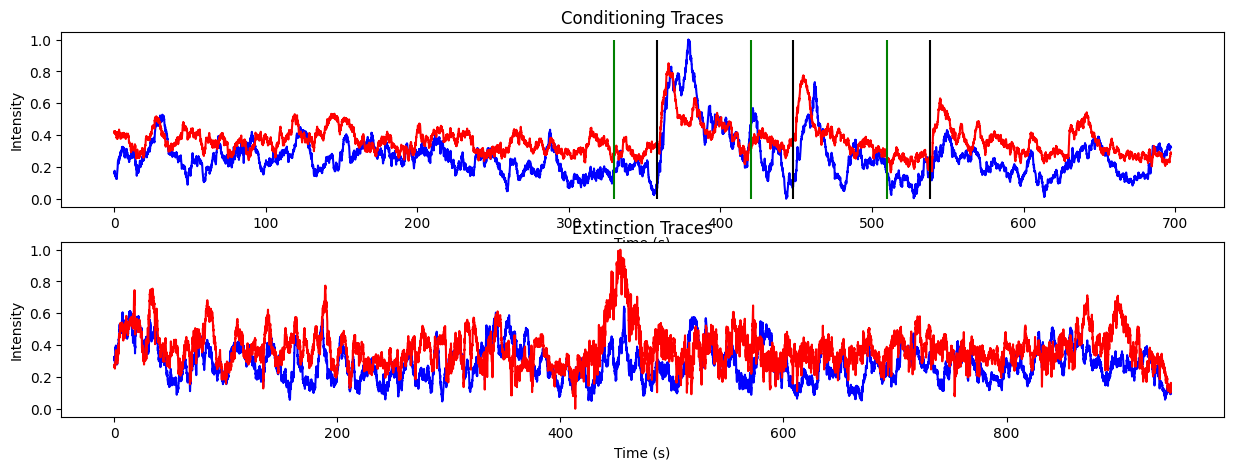

In [113]:
# I used the ax syntax in order to create two subplots, one for conditioning and one for extinction
fig, ax = plt.subplots(2,1, figsize = (15, 5))
ax[0].plot(time_conditioning, conditioning_traces[:, 0], color = 'blue')
ax[0].plot(time_conditioning, conditioning_traces[:, 1], color = 'red')
ax[0].set_title('Conditioning Traces')
ax[0].set_ylabel('Intensity')
ax[0].set_xlabel('Time (s)')
ax[0].vlines(shock_index, 0, 1, color = 'black')
ax[0].vlines(tone_index, 0, 1, color = 'green')

ax[1].plot(time_extinction, extinction_traces[:, 0], color = 'blue')
ax[1].plot(time_extinction, extinction_traces[:, 1], color = 'red')
ax[1].set_title('Extinction Traces')
ax[1].set_ylabel('Intensity')
ax[1].set_xlabel('Time (s)')

plt.show()



There appears to be some relationship between responses in conditioning and extinction sessions. During conditioning both ROIs appear to increase in activity in relation to the tone and shocks, indicating that both of those cells are response to the paried stimuli. However, the second ROI displayed in red seems to be more consistent in activity compared to the first ROI in blue. During extinction where the shcok is not paried with the tone, there appears to be some similar activity, but it is significantly less consistent. The second ROI in red still seems to display increased activity like in the conditioning session, but the first ROI in blue seems to show significantly less activity and its even less consistent compared to the conditioning session. **I am not sure why my graph looks slightly distorted with the labeling.

In [114]:
# I used the code syntax from our previous notebook on 4/2 to create my variables and predictors
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array),'tone onset': tone_array,'shock onset': shock_array})
tone_array_extinction = np.zeros(14210)
for i in range(14210):
    for t in tone_index:
        if i >= (t-15)*15 and i <= (t+30)*15:
            tone_array_extinction[i] = 1

extinction_predictors = df(data={'Intercept': np.ones_like(tone_array_extinction),'tone onset': tone_array_extinction})



In [117]:
# I used the syntax from our previous notebook on 4/2 to store the correlation coefficient for conditioning
r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()
  r = pearsonr(trace_temp, predicted_trace)
  r_model_conditioning[i] = r.statistic

In [118]:
# I used the syntax from our previous notebook on 4/2 to store the correlation coefficient for extinction
r_index_extinction = np.zeros(63)

for i in range(63):
  trace_temp = extinction_traces[:,i]
  model = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model_results = model.fit()
  predicted_trace = model_results.predict()
  r = pearsonr(trace_temp, predicted_trace)
  r_index_extinction[i] = r.statistic


In [116]:
# I used pearsonr to obtain the correlation coefficient
r_conditioning_vs_extinction = pearsonr(r_model_conditioning, r_index_extinction)
print(r_conditioning_vs_extinction.statistic)

0.12619688891011477


Text(0, 0.5, 'R Extinction')

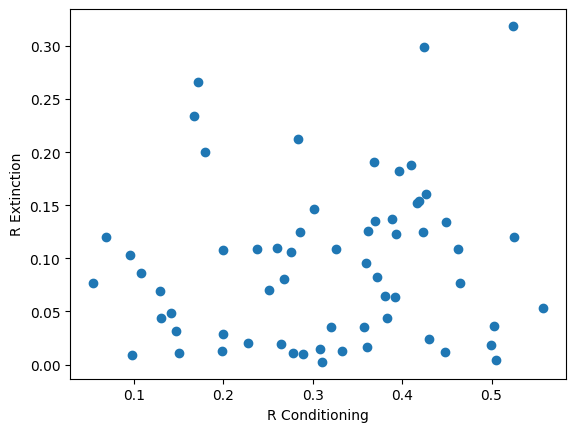

In [115]:
# I used the scatter syntax in order to create a scatter plot with the R conditioning on the x-axis and R extinction on the y-axis
plt.scatter(r_model_conditioning, r_index_extinction)
plt.xlabel('R Conditioning')
plt.ylabel('R Extinction')

Based on the graph and the correlation coefficient, there is a weak positive relationship between the response strength of the cell during conditioning and extinction. This suggests that the neurons responding to the tone and shock during conditioning may not be the same neruons that respond to the tone during extinction.

* Notes: high R2 for conditioning (learning) and low R2 for extinction, separate neruons for learning and extinction but if they are relatively the same, the neurons for learning and extinction are the same